# Two-asset Merton with correlated returns

Log-utility consumption-portfolio choice between two risky assets with
correlated lognormal returns. Exercises `MultivariateNormal` as a
2-dimensional shock primitive.

## Problem

At each period, the agent picks consumption $c_t$ and portfolio share
$\pi_t \in [0, 1]$ allocated to asset 1 (with $1 - \pi_t$ in asset 2).
Log returns of the two assets are correlated:

$$ (r^1_t, r^2_t) \sim \mathcal{N}(\mu, \Sigma), \qquad
   \Sigma = \begin{pmatrix} \sigma_1^2 & \rho \sigma_1 \sigma_2 \\ \rho \sigma_1 \sigma_2 & \sigma_2^2 \end{pmatrix}. $$

Wealth dynamics:

$$ w_{t+1} = (w_t - c_t)\,\bigl(\pi_t\,e^{r^1_t} + (1 - \pi_t)\,e^{r^2_t}\bigr). $$

Reward $u(c) = \log c$, discount $\beta$.

## Closed-form structure (log utility)

Under log utility, **consumption and portfolio choice decouple**:

- **Consumption rate** is constant in wealth and time, $c^*_t / w_t = 1 - \beta$
  (same as 1-asset Merton).
- **Portfolio share** $\pi^*$ is constant in wealth and solves the
  one-shot FOC

$$ \mathbb{E}\!\left[ \frac{e^{r^1} - e^{r^2}}{\pi\,e^{r^1} + (1-\pi)\,e^{r^2}} \right] = 0. $$

(Effectively, log-utility makes the agent Kelly-optimal: maximise the
expected log return of the portfolio each period.)

No closed-form solution for $\pi^*$ in discrete time, but the FOC is a
1-D root-finding problem on a smooth function — that's our numerical
benchmark.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    Problem,
    solve,
)
from bellgrid.grids import RegularGrid, WarpedGrid
from bellgrid.shocks import MultivariateNormal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
# Two risky assets — neither dominates the other across all ρ. Asset 2
# has higher Sharpe (μ/σ = 0.40 vs 0.30), but asset 1 has higher
# expected gross return; in the diversifying regime (low / negative ρ)
# you want a mix; for very high ρ the diversification benefit vanishes
# and you go all-in on the higher-Sharpe asset.
beta = 0.96
mu = np.array([0.06, 0.04])      # mean log returns
sigma = np.array([0.20, 0.10])   # vols
rho = 0.1                         # correlation
T = 20
expected_rate = 1.0 - beta


def cov_matrix(rho):
    return np.array([
        [sigma[0]**2,         rho * sigma[0] * sigma[1]],
        [rho * sigma[0] * sigma[1], sigma[1]**2],
    ])

## Numerical benchmark: solve the portfolio FOC

Use MVN Gauss-Hermite quadrature (same engine as bellgrid uses
internally) to evaluate the FOC, then bracket-and-bisect for the root.

In [3]:
def optimal_pi(mu, sigma, rho, n_quad=11):
    """Solve E[(R1 - R2) / (pi R1 + (1-pi) R2)] = 0 by bracket + bisect."""
    cov = cov_matrix(rho)
    L = np.linalg.cholesky(cov)
    raw_z, raw_w = np.polynomial.hermite_e.hermegauss(n_quad)
    w_1d = raw_w / math.sqrt(2.0 * math.pi)
    z_mesh = np.meshgrid(raw_z, raw_z, indexing="ij")
    w_mesh = np.meshgrid(w_1d, w_1d, indexing="ij")
    z_flat = np.stack([m.flatten() for m in z_mesh], axis=-1)
    w_flat = np.prod(np.stack([m.flatten() for m in w_mesh], axis=-1), axis=-1)
    r = mu + z_flat @ L.T
    R = np.exp(r)  # (N_q, 2)
    R1, R2 = R[:, 0], R[:, 1]

    def foc(pi):
        return (w_flat * (R1 - R2) / (pi * R1 + (1 - pi) * R2)).sum()

    # The FOC is monotone-decreasing in pi between (0, 1); bracket + bisect.
    lo, hi = 1e-6, 1 - 1e-6
    f_lo, f_hi = foc(lo), foc(hi)
    if f_lo * f_hi > 0:
        return 0.0 if f_lo < 0 else 1.0
    for _ in range(100):
        mid = 0.5 * (lo + hi)
        f_mid = foc(mid)
        if abs(f_mid) < 1e-12 or hi - lo < 1e-10:
            return mid
        if f_lo * f_mid < 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
    return 0.5 * (lo + hi)


pi_star_numerical = optimal_pi(mu, sigma, rho)
print(f"Numerical FOC π* (ρ={rho}): {pi_star_numerical:.4f}")
print(f"Log-utility consumption rate: c/w = 1 - β = {expected_rate:.4f}")

Numerical FOC π* (ρ=0.1): 0.9360
Log-utility consumption rate: c/w = 1 - β = 0.0400


## Bellgrid problem

One state (wealth), two actions (consume + portfolio share), one
`MultivariateNormal` shock with 2 dimensions. The terminal reward is
the closed-form $V(w) = A + B \log w$, where $A$ involves the
expected log return of the optimal portfolio.

In [4]:
def expected_log_portfolio_return(pi, mu, sigma, rho, n_quad=11):
    cov = cov_matrix(rho)
    L = np.linalg.cholesky(cov)
    raw_z, raw_w = np.polynomial.hermite_e.hermegauss(n_quad)
    w_1d = raw_w / math.sqrt(2.0 * math.pi)
    z_mesh = np.meshgrid(raw_z, raw_z, indexing="ij")
    w_mesh = np.meshgrid(w_1d, w_1d, indexing="ij")
    z_flat = np.stack([m.flatten() for m in z_mesh], axis=-1)
    w_flat = np.prod(np.stack([m.flatten() for m in w_mesh], axis=-1), axis=-1)
    R = np.exp(mu + z_flat @ L.T)
    return float((w_flat * np.log(pi * R[:, 0] + (1 - pi) * R[:, 1])).sum())


log_growth = expected_log_portfolio_return(pi_star_numerical, mu, sigma, rho)
B = 1.0 / (1.0 - beta)
A = (
    math.log(1.0 - beta) / (1.0 - beta)
    + (beta / (1.0 - beta) ** 2) * (math.log(beta) + log_growth)
)


def transition(state, action, shock, _t):
    w = state["wealth"]
    c = action["consume"]
    pi = action["share"]
    R1 = torch.exp(shock["r1"])
    R2 = torch.exp(shock["r2"])
    return {"wealth": (w - c) * (pi * R1 + (1 - pi) * R2)}


def reward(_state, action, _shock, _t):
    return torch.log(action["consume"])


def terminal_reward(state):
    return A + B * torch.log(state["wealth"])


problem = Problem(
    states=[ContinuousState("wealth", warp="asinh", range=(1e-3, 200.0))],
    actions=[
        ContinuousAction("consume", bounds=(1e-6, "wealth")),
        ContinuousAction("share", bounds=(0.0, 1.0)),
    ],
    transition=transition,
    reward=reward,
    shocks=[
        MultivariateNormal(
            names=("r1", "r2"),
            mean=mu,
            cov=cov_matrix(rho),
        )
    ],
    horizon=range(0, T),
    discount=beta,
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={"wealth": WarpedGrid(n=128)},
    action_grid={
        "consume": RegularGrid(n=200),
        "share": RegularGrid(n=51),
    },
    solver=BackwardInduction(n_quad=7),
)

## Consumption rate and portfolio share vs wealth

Both should be **flat in wealth** under log utility (separability),
matching the analytical values: $c/w = 1 - \beta$ and
$\pi = \pi^*_{\mathrm{FOC}}$.

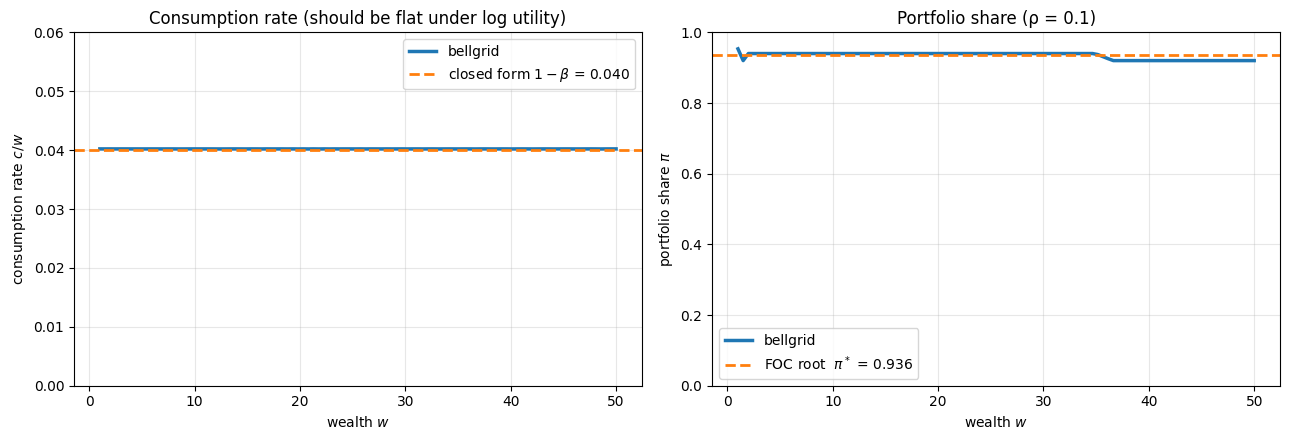

In [5]:
w_query = torch.linspace(1.0, 50.0, 100, dtype=torch.float64)
actions = policy({"wealth": w_query}, t=T // 2)
c_bg = actions["consume"].numpy()
pi_bg = actions["share"].numpy()
rate_bg = c_bg / w_query.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(w_query.numpy(), rate_bg, lw=2.5, label="bellgrid")
ax1.axhline(expected_rate, color="C1", ls="--", lw=2, label=f"closed form $1-\\beta$ = {expected_rate:.3f}")
ax1.set_xlabel("wealth $w$")
ax1.set_ylabel("consumption rate $c/w$")
ax1.set_title("Consumption rate (should be flat under log utility)")
ax1.set_ylim(0.0, 0.06)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(w_query.numpy(), pi_bg, lw=2.5, label="bellgrid")
ax2.axhline(pi_star_numerical, color="C1", ls="--", lw=2,
            label=f"FOC root  $\\pi^*$ = {pi_star_numerical:.3f}")
ax2.set_xlabel("wealth $w$")
ax2.set_ylabel("portfolio share $\\pi$")
ax2.set_title(f"Portfolio share (ρ = {rho})")
ax2.set_ylim(0.0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Diversification: how correlation affects the optimal share

As $\rho$ varies, the optimal share between equity and bonds shifts.
Sweep $\rho$ from negative (anti-correlated) to highly positive and
plot bellgrid's chosen share alongside the FOC root.

Intuition: when assets are **highly correlated**, the diversification
benefit of holding both shrinks, and the agent tilts harder toward the
asset with higher Sharpe ratio. Anti-correlation enables a better-
diversified portfolio with more middle-of-the-road shares.

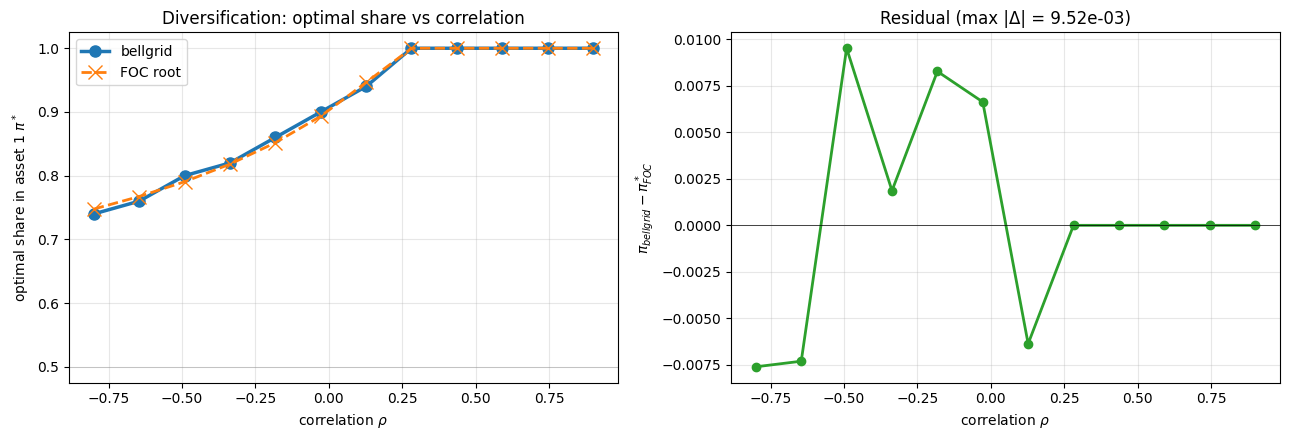

In [6]:
rho_grid = np.linspace(-0.8, 0.9, 12)
pi_foc = np.array([optimal_pi(mu, sigma, r) for r in rho_grid])

pi_bg_sweep = []
for r in rho_grid:
    log_g = expected_log_portfolio_return(optimal_pi(mu, sigma, r), mu, sigma, r)
    A_r = (
        math.log(1.0 - beta) / (1.0 - beta)
        + (beta / (1.0 - beta) ** 2) * (math.log(beta) + log_g)
    )

    def terminal_r(state, A_r=A_r):
        return A_r + B * torch.log(state["wealth"])

    problem_r = Problem(
        states=problem.states,
        actions=problem.actions,
        transition=transition,
        reward=reward,
        shocks=[
            MultivariateNormal(names=("r1", "r2"), mean=mu, cov=cov_matrix(r))
        ],
        horizon=range(0, T),
        discount=beta,
        terminal_reward=terminal_r,
    )
    p_r, _ = solve(
        problem_r,
        state_grid={"wealth": WarpedGrid(n=128)},
        action_grid={
            "consume": RegularGrid(n=200),
            "share": RegularGrid(n=51),
        },
        solver=BackwardInduction(n_quad=7),
    )
    # Pick the share at a representative wealth (it's constant in wealth anyway)
    pi_bg_sweep.append(
        p_r({"wealth": torch.tensor([10.0], dtype=torch.float64)}, t=T // 2)["share"].item()
    )
pi_bg_sweep = np.array(pi_bg_sweep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(rho_grid, pi_bg_sweep, "o-", lw=2.5, label="bellgrid", markersize=8)
ax1.plot(rho_grid, pi_foc, "x--", lw=2, color="C1", label="FOC root", markersize=10)
ax1.axhline(0.5, color="gray", lw=0.5, alpha=0.5)
ax1.set_xlabel("correlation $\\rho$")
ax1.set_ylabel("optimal share in asset 1 $\\pi^*$")
ax1.set_title("Diversification: optimal share vs correlation")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(rho_grid, pi_bg_sweep - pi_foc, "o-", lw=2, color="C2")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.set_xlabel("correlation $\\rho$")
ax2.set_ylabel("$\\pi_{bellgrid} - \\pi^*_{FOC}$")
ax2.set_title(f"Residual (max |Δ| = {np.abs(pi_bg_sweep - pi_foc).max():.2e})")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()